
# EcoType: Forest Cover Type Prediction Using Machine Learning

This notebook covers:

1. Data Collection  
2. Data Understanding  
3. Data Cleaning & Transformation  
4. Feature Engineering  
5. Exploratory Data Analysis (EDA)  
6. Class Imbalance Handling  
7. Feature Selection  
8. Model Building  
9. Hyperparameter Tuning  
10. Finalize and Save Best Model


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:

# =============================================================================
# 1. DATA COLLECTION
# =============================================================================

df = pd.read_csv("cover_type.csv")

print("Dataset Loaded Successfully")


Dataset Loaded Successfully


In [3]:

# =============================================================================
# 2. DATA UNDERSTANDING
# =============================================================================

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe())

print("\nTarget Class Distribution:")
print(df['Cover_Type'].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


Shape: (145890, 13)

Columns:
Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 

In [5]:
# =============================================================================
# 3. DATA CLEANING & TRANSFORMATION
# =============================================================================

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# View actual column names
print("Columns:")
print(df.columns)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Safely remove target column
if 'Cover_Type' in numeric_cols:
    numeric_cols.remove('Cover_Type')

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# =============================================================================
# HANDLE MISSING VALUES
# =============================================================================

for col in numeric_cols:
    
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values Handled")

# =============================================================================
# OUTLIER HANDLING USING IQR
# =============================================================================

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

print("Outliers Handled")

# =============================================================================
# SKEWNESS FIX
# =============================================================================

skewed_features = []

for col in numeric_cols:
    
    if abs(df[col].skew()) > 1:
        
        df[col] = np.log1p(
            df[col] - df[col].min()
        )

        skewed_features.append(col)

print("\nSkewed Features:")
print(skewed_features)

Columns:
Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

Missing Values Handled
Outliers Handled

Skewed Features:
[]


In [6]:

# =============================================================================
# 4. FEATURE ENGINEERING
# =============================================================================

df['Distance_To_Hydrology'] = np.sqrt(
    df['Horizontal_Distance_To_Hydrology']**2 +
    df['Vertical_Distance_To_Hydrology']**2
)

df['Mean_Hillshade'] = (
    df['Hillshade_9am'] +
    df['Hillshade_Noon'] +
    df['Hillshade_3pm']
) / 3

df['Hydro_Road_Distance_Diff'] = (
    df['Horizontal_Distance_To_Hydrology'] -
    df['Horizontal_Distance_To_Roadways']
)

# Encoding
encoders = {}

for col in cat_cols:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col].astype(str))
    
    encoders[col] = le

# Save Encoder
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Feature Engineering Completed")


Feature Engineering Completed


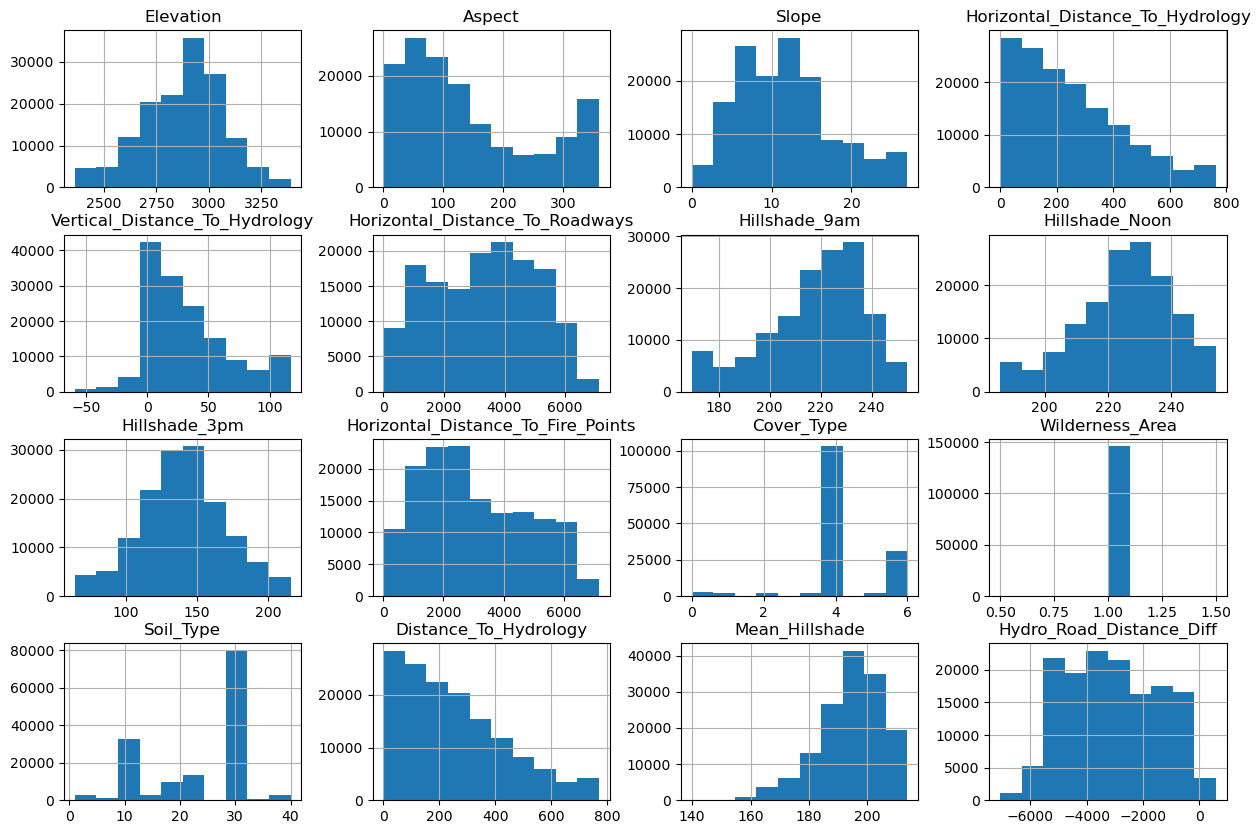

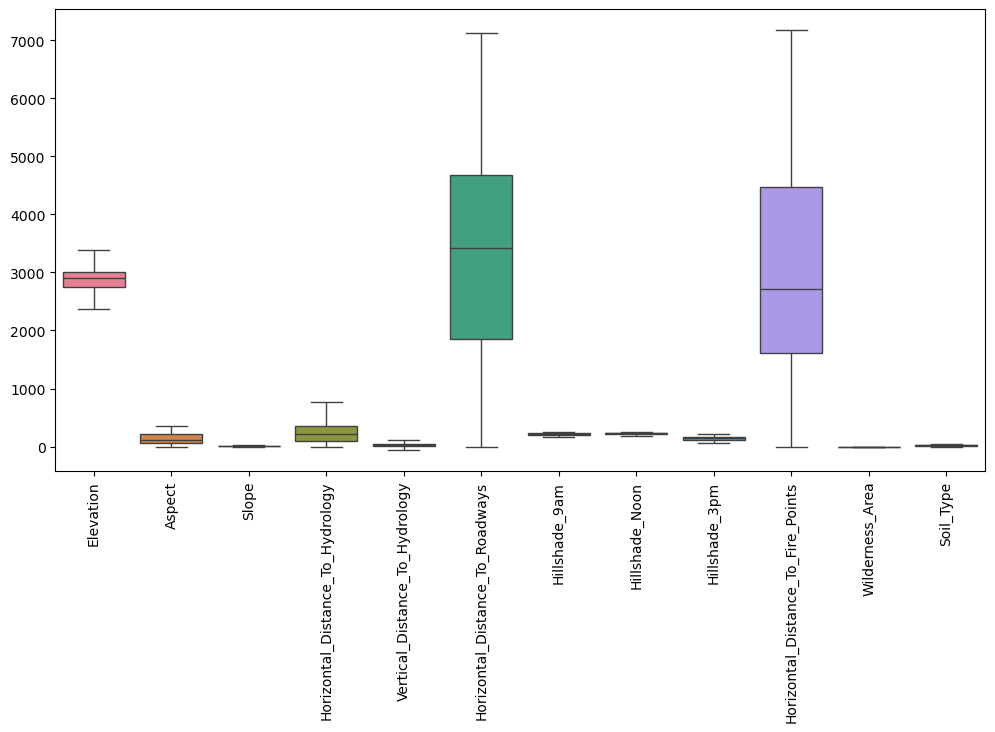

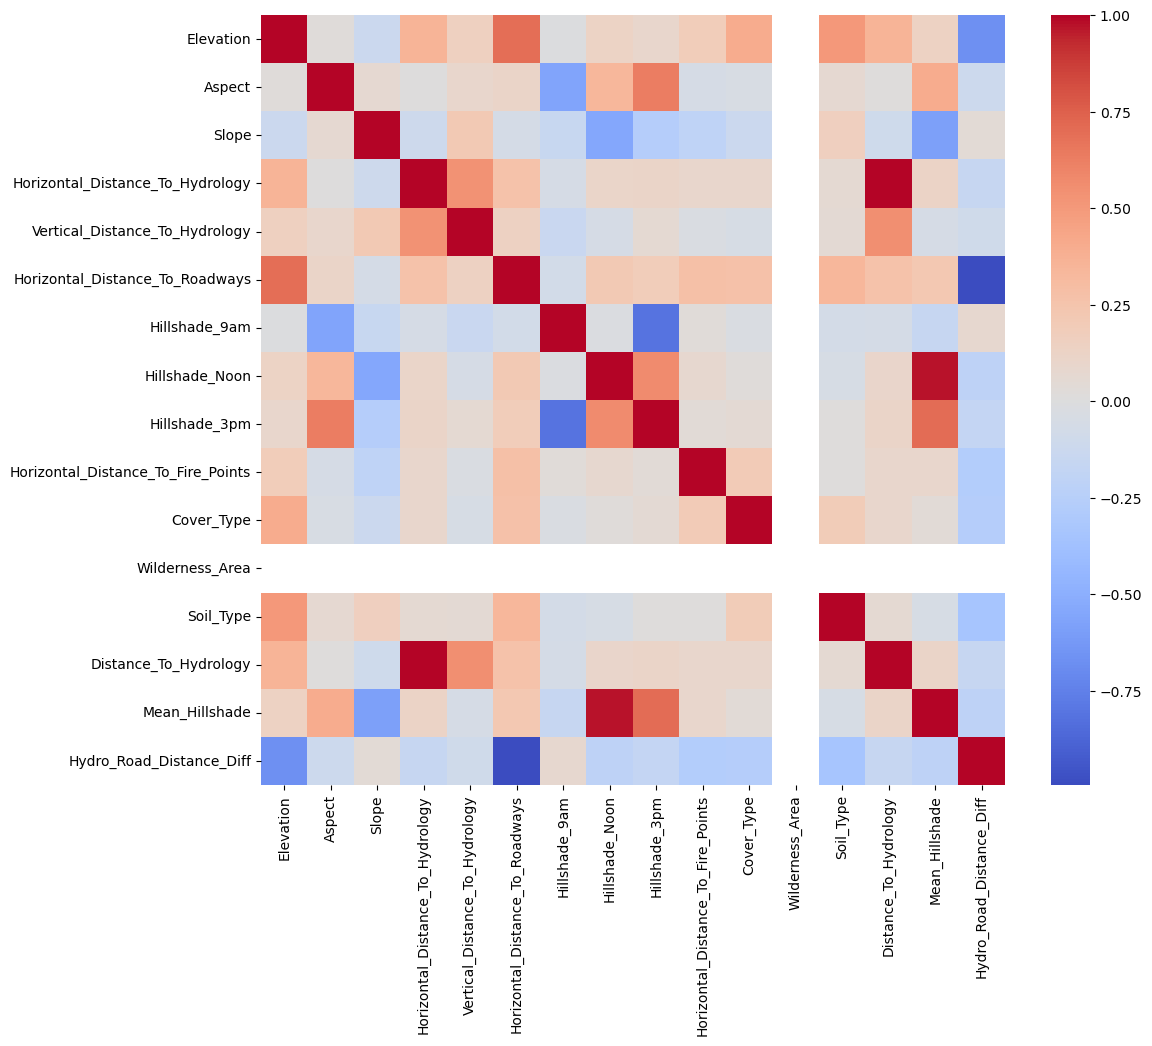

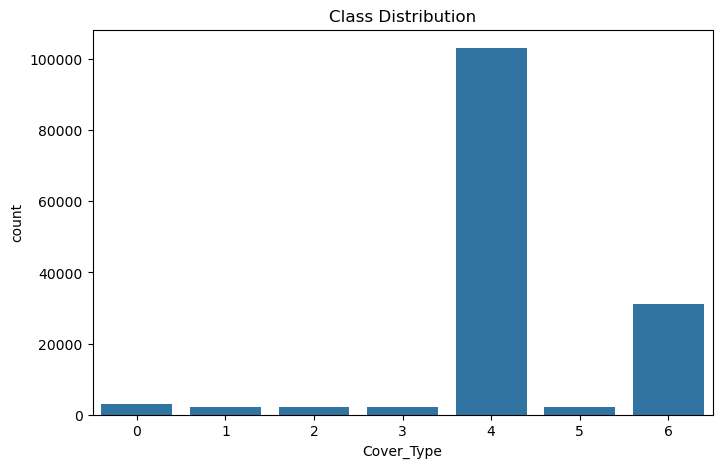

In [7]:

# =============================================================================
# 5. EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================

# Histogram
df.hist(figsize=(15, 10))
plt.show()

# Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=90)
plt.show()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

# Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=df['Cover_Type'])
plt.title("Class Distribution")
plt.show()


In [8]:

# =============================================================================
# 6. CLASS IMBALANCE HANDLING
# =============================================================================

X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

ros = RandomOverSampler(random_state=42)

X, y = ros.fit_resample(X, y)

print("Class Distribution After Oversampling:")
print(pd.Series(y).value_counts())


Class Distribution After Oversampling:
Cover_Type
0    103071
4    103071
6    103071
3    103071
5    103071
2    103071
1    103071
Name: count, dtype: int64


Selected Features:
['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Soil_Type', 'Distance_To_Hydrology', 'Mean_Hillshade', 'Hydro_Road_Distance_Diff']


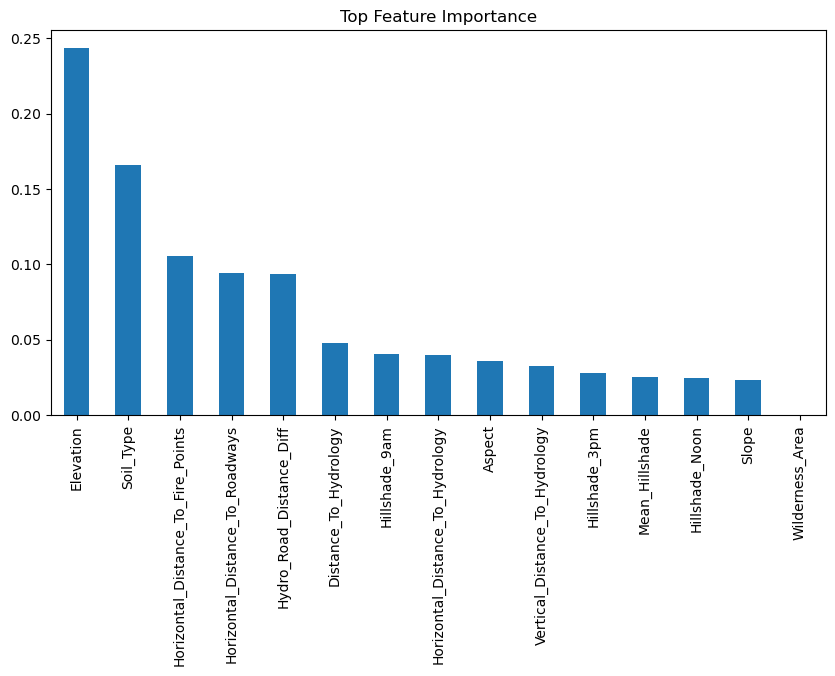

In [9]:

# =============================================================================
# 7. FEATURE SELECTION
# =============================================================================

rf_selector = RandomForestClassifier(random_state=42)

rf_selector.fit(X, y)

importance = pd.Series(
    rf_selector.feature_importances_,
    index=X.columns
)

top_features = importance[importance > 0.01].index.tolist()

X = X[top_features]

print("Selected Features:")
print(top_features)

# Feature Importance Plot
importance.sort_values(ascending=False).head(15).plot(kind='bar', figsize=(10,5))
plt.title("Top Feature Importance")
plt.show()


In [11]:
# =============================================================================
# 8. MODEL BUILDING 
# =============================================================================

print("Starting Model Training...")

# Scale Data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =============================================================================
# MODELS
# =============================================================================

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=500,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "XGBoost": XGBClassifier(
        n_estimators=50,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
}

# =============================================================================
# TRAINING
# =============================================================================

results = {}

for name, model in models.items():

    print("\n" + "="*50)
    print(f"Training {name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print(f"{name} Accuracy: {accuracy:.4f}")

# =============================================================================
# FINAL RESULTS
# =============================================================================

print("\n" + "="*50)
print("FINAL MODEL ACCURACY")
print("="*50)

for model_name, score in results.items():

    print(f"{model_name}: {score:.4f}")

# =============================================================================
# BEST MODEL
# =============================================================================

best_model_name = max(results, key=results.get)

best_model = models[best_model_name]

print("\nBest Model:", best_model_name)

Starting Model Training...

Training Random Forest...
Random Forest Accuracy: 0.8788

Training Decision Tree...
Decision Tree Accuracy: 0.8431

Training Logistic Regression...
Logistic Regression Accuracy: 0.6816

Training KNN...
KNN Accuracy: 0.9797

Training XGBoost...
XGBoost Accuracy: 0.8800

FINAL MODEL ACCURACY
Random Forest: 0.8788
Decision Tree: 0.8431
Logistic Regression: 0.6816
KNN: 0.9797
XGBoost: 0.8800

Best Model: KNN


In [13]:
# =============================================================================
# HYPERPARAMETER TUNING 
# =============================================================================

print("Starting Hyperparameter Tuning...")

param_grid = {

    'n_estimators': [50, 100],

    'max_depth': [10, 15],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2]
}

random_search = RandomizedSearchCV(

    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    param_distributions=param_grid,

    n_iter=3,              # Reduced iterations

    cv=2,                  # Faster cross validation

    verbose=1,

    random_state=42,

    n_jobs=-1
)

# Train
random_search.fit(X_train, y_train)

# Best Model
best_model = random_search.best_estimator_

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Score:")
print(random_search.best_score_)

Starting Hyperparameter Tuning...
Fitting 2 folds for each of 3 candidates, totalling 6 fits

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}

Best Score:
0.8792440026588921


In [14]:
# =============================================================================
# 9. FINALIZE AND SAVE BEST MODEL 
# =============================================================================

print("Performing Cross Validation...")

# Faster Cross Validation
cv_score = cross_val_score(
    best_model,
    X_scaled,
    y,
    cv=2,              # Reduced folds for speed
    n_jobs=-1
).mean()

print("\nCross Validation Accuracy:")
print(round(cv_score, 4))

# =============================================================================
# SAVE MODEL FILES
# =============================================================================

print("\nSaving Model Files...")

# Save Best Model
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save Scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save Top Features
with open("top_features.pkl", "wb") as f:
    pickle.dump(top_features, f)

# Save Skewed Features
with open("skewed_features.pkl", "wb") as f:
    pickle.dump(skewed_features, f)

print("\nModel Saved Successfully!")

print("\nProject Pipeline Completed Successfully!")

Performing Cross Validation...

Cross Validation Accuracy:
0.7952

Saving Model Files...

Model Saved Successfully!

Project Pipeline Completed Successfully!
